In [78]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import seaborn as sns

In [79]:
df  = pd.read_csv(r"C:\Users\user\Downloads\Customer Churn.csv")

In [80]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [82]:
df['TotalCharges'] = df['TotalCharges'].replace(" ","0")
df['TotalCharges'] = df['TotalCharges'].astype("float")

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [84]:
df.isnull().sum().sum()

np.int64(0)

In [85]:
df.duplicated().sum().sum()

np.int64(0)

In [86]:
df["SeniorCitizen"]

0       0
1       0
2       0
3       0
4       0
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: SeniorCitizen, Length: 7043, dtype: int64

In [87]:
def conv(value):
    if value == 1:
        return "senior"
    else:
        return "younger"
df["SeniorCitizen"] = df['SeniorCitizen'].apply(conv)


In [88]:
df['Churn']

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: str

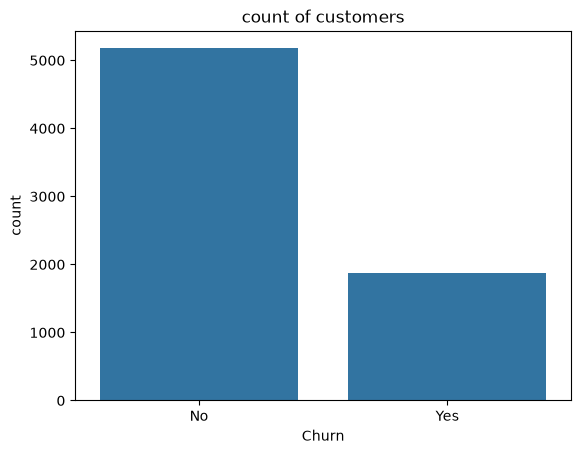

In [89]:
sns.countplot(x = 'Churn',data = df)
plt.title("count of customers")
plt.show()

Text(0.5, 1.0, 'percentges of customers')

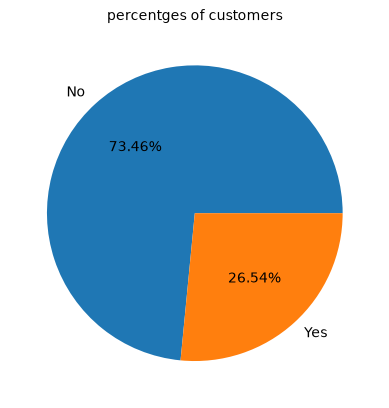

In [90]:
gb = df.groupby("Churn").agg({"Churn":"count"})
plt.pie(gb['Churn'],labels = gb.index,autopct= "%1.2f%%")
plt.title("percentges of customers",fontsize = 10)

In [ ]:
# from the given pie chart that we can conculed that 26 percenage of customers are churned out 

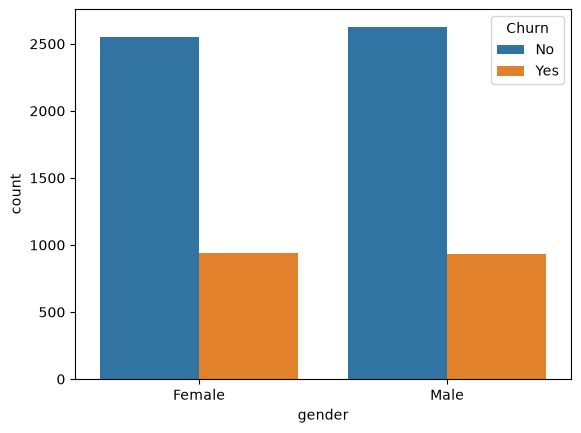

<Figure size 400x400 with 0 Axes>

In [103]:
sns.countplot(x= 'gender',data = df,hue = 'Churn')
plt.figure(figsize = (4,4))
plt.show()

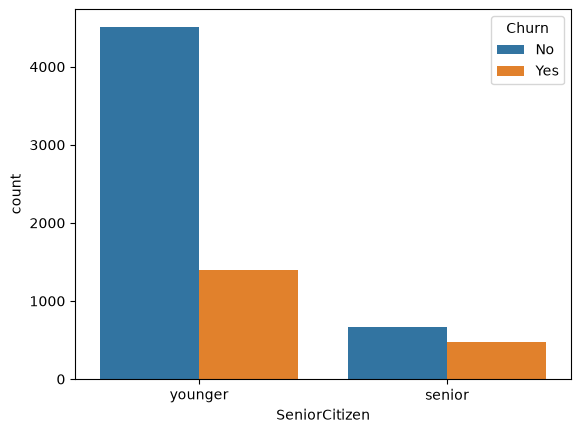

<Figure size 400x400 with 0 Axes>

In [110]:
sns.countplot(x = 'SeniorCitizen',data = df,hue = 'Churn')
plt.figure(figsize=(4,4))
plt.show()

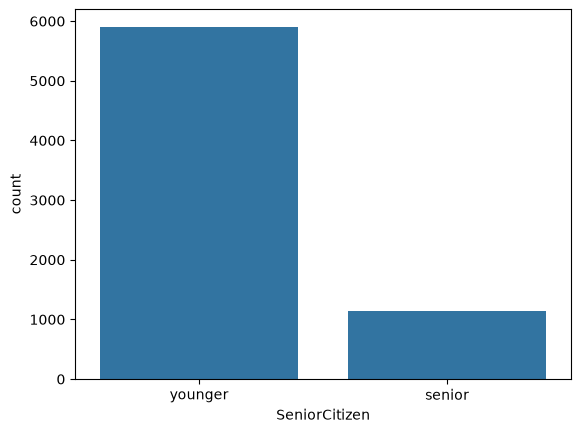

In [115]:
sns.countplot(x = 'SeniorCitizen',data = df)
plt.show()

<Figure size 300x300 with 0 Axes>

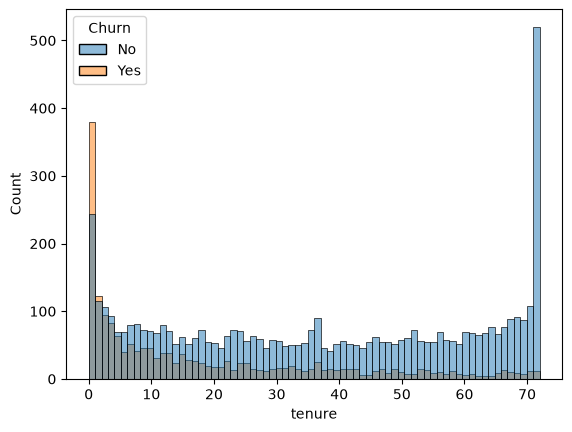

<Figure size 300x300 with 0 Axes>

In [125]:
sns.histplot(x= 'tenure',data = df,bins = 70,hue = 'Churn')
plt.figure(figsize=(3,3))

In [ ]:
# people who used for long days they are not churned 

<Axes: xlabel='Contract', ylabel='count'>

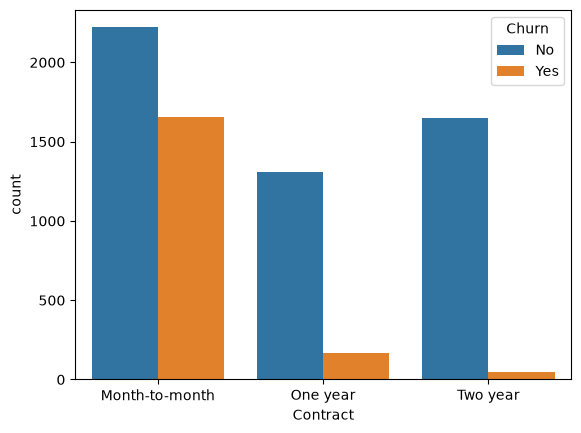

In [135]:
sns.countplot(x = 'Contract',data = df,hue = 'Churn')


In [ ]:
"""people who have monthlu contract constract like to churn

In [138]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

✓ Saved: churn_categorical_subplots.png


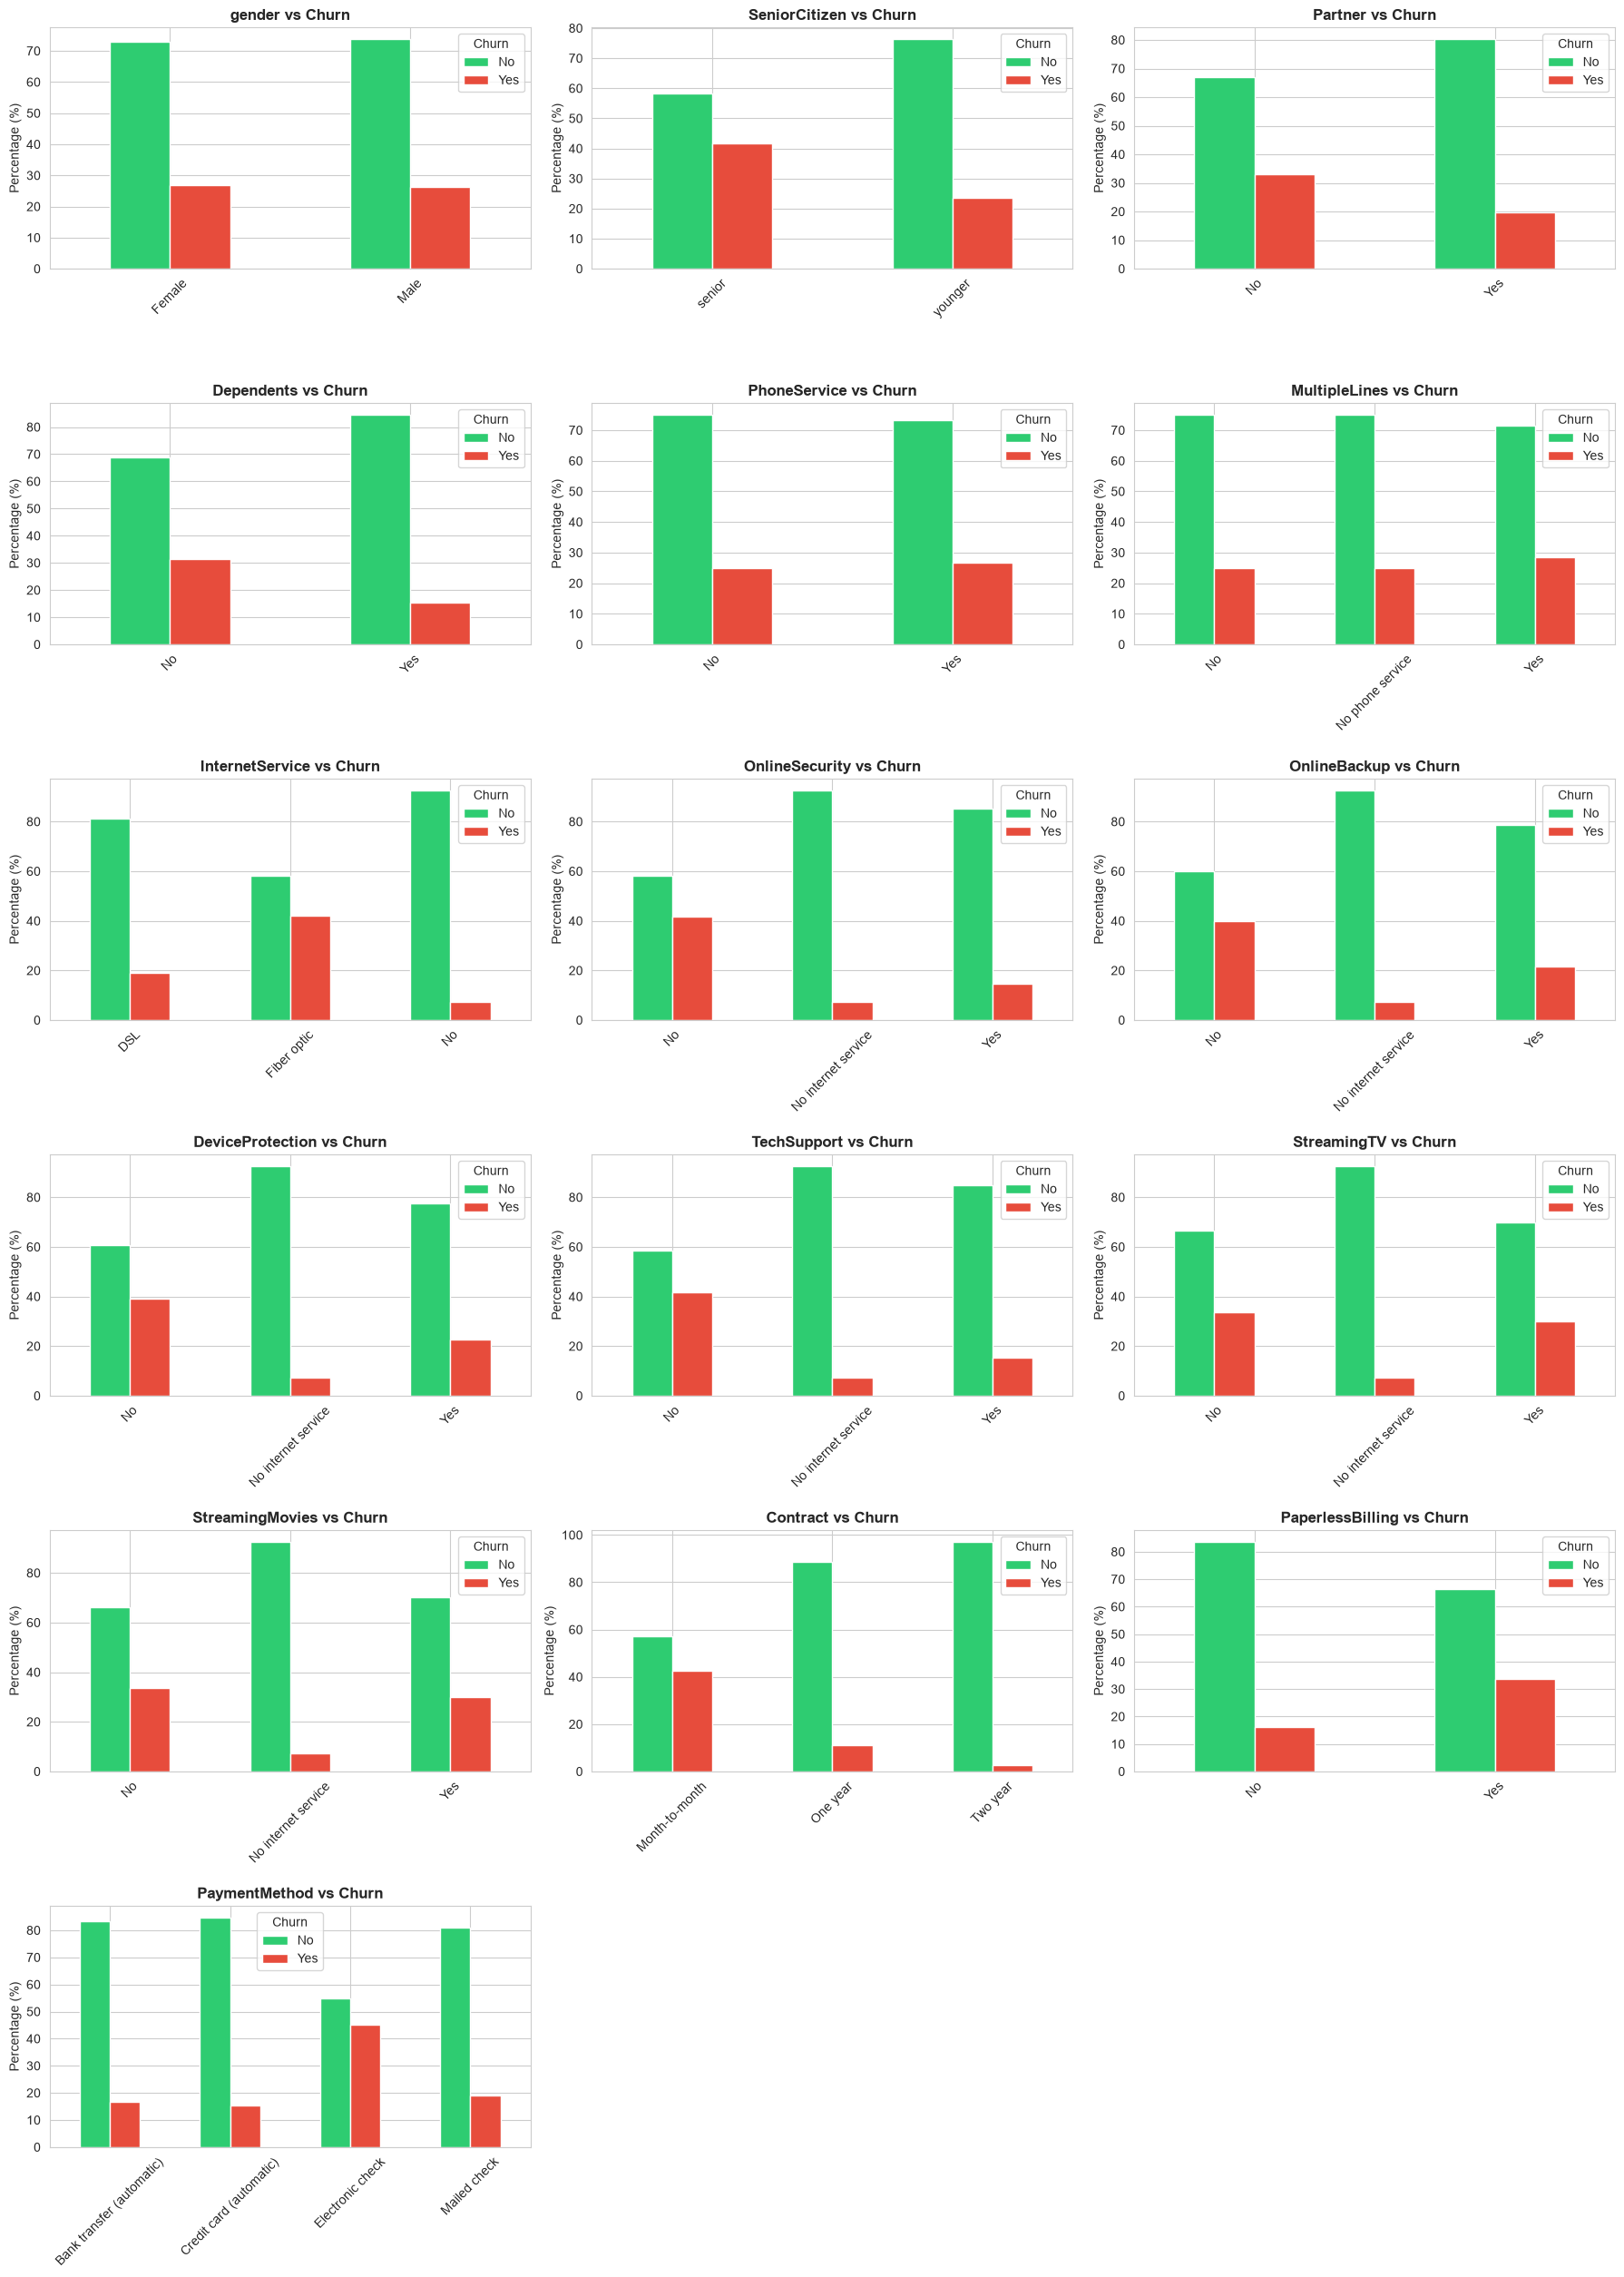

✓ Saved: churn_numerical_subplots.png


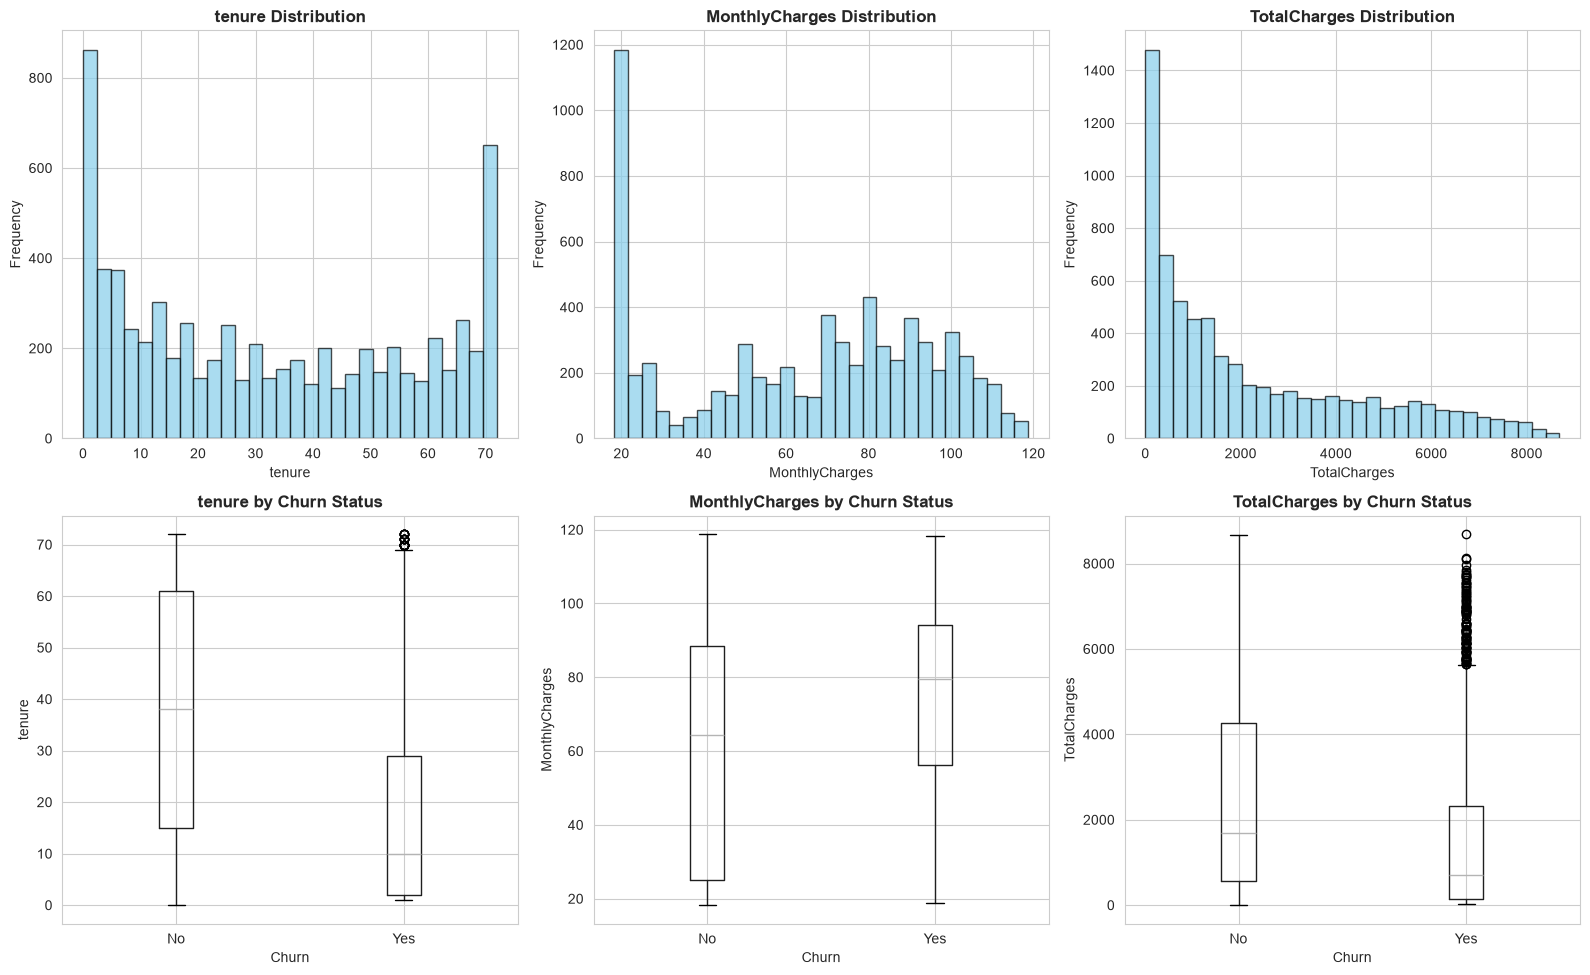


CHURN ANALYSIS SUMMARY


In [142]:


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 24)

# ============================================================================
# PART 1: CATEGORICAL FEATURES vs CHURN (3 cols x 7 rows)
# ============================================================================
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 
    'PhoneService', 'MultipleLines', 'InternetService', 
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(7, 3, figsize=(18, 28))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    churn_cross = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    churn_cross.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(title='Churn', labels=['No', 'Yes'])
    axes[idx].tick_params(axis='x', rotation=45)

# Hide the extra subplots
for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('churn_categorical_subplots.png', dpi=300, bbox_inches='tight')
print("✓ Saved: churn_categorical_subplots.png")
plt.show()

# ============================================================================
# PART 2: NUMERICAL FEATURES (tenure, MonthlyCharges, TotalCharges)
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Row 1: Distribution (histograms)
for idx, col in enumerate(numerical_cols):
    axes[0, idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[0, idx].set_xlabel(col)
    axes[0, idx].set_ylabel('Frequency')

# Row 2: Churn relationship (box plots)
for idx, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='Churn', ax=axes[1, idx])
    axes[1, idx].set_title(f'{col} by Churn Status', fontsize=12, fontweight='bold')
    axes[1, idx].set_xlabel('Churn')
    axes[1, idx].set_ylabel(col)
    plt.sca(axes[1, idx])
    plt.xticks([1, 2], ['No', 'Yes'])

plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.savefig('churn_numerical_subplots.png', dpi=300, bbox_inches='tight')
print("✓ Saved: churn_numerical_subplots.png")
plt.show()

# ============================================================================
# PART 3: KEY INSIGHTS SUMMARY
# ============================================================================
print("\n" + "="*60)
print("CHURN ANALYSIS SUMMARY")
print("="*60)

